In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression ,LogisticRegression,ridge_regression
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv('student_performance.csv.xls')

In [8]:
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [9]:
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [10]:
df['grade'].unique()

array(['A', 'B', 'C', 'D', 'F'], dtype=object)

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [12]:
grade_map = {
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1
}

df['grade'] = df['grade'].map(grade_map)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    993796 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 45.8 MB


<Axes: ylabel='grade'>

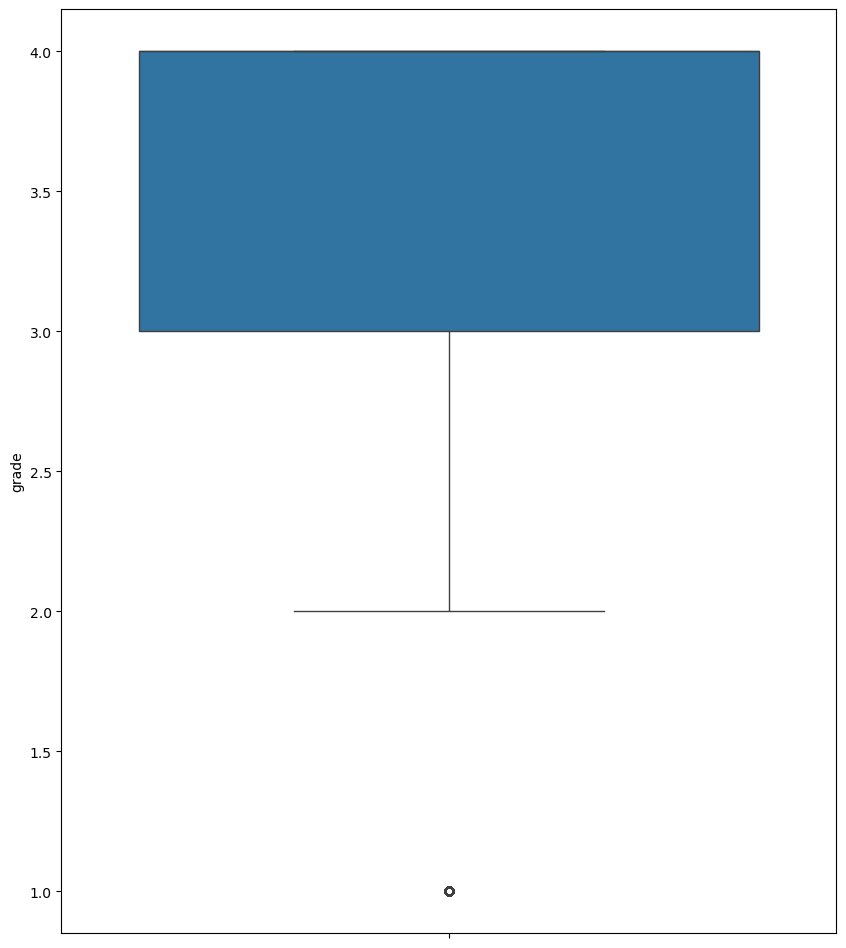

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,12))

sns.boxplot(data=df ,y ='grade')

In [15]:
def Outlier(df):
   # IQR : Q1 - Q3 { Q1 - 1.5 * IQR | Q3 + 1.5 *IQR }
   col = list(df.columns)
   for i in col:
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    print(f"Lower limit  {lower_bound}")
    upper_bound=Q3+1.5*IQR
    print(f"Upper limit  {upper_bound}")

    df = df[(df[i] >= lower_bound) & (df[i] <= upper_bound)]
   return df

In [16]:

df = Outlier(df)


Lower limit  -499998.5
Upper limit  1499999.5
Lower limit  -3.799999999999997
Upper limit  33.8
Lower limit  58.05
Upper limit  112.05
Lower limit  0.8000000000000007
Upper limit  11.2
Lower limit  34.49999999999999
Upper limit  139.3
Lower limit  1.5
Upper limit  5.5


In [17]:
df.columns

Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='object')

In [18]:
# Features : {Edit}

In [19]:
x = df.drop('grade',axis = 1)
y = df['grade']

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,test_size=0.3,random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler
scl =   StandardScaler()
x_test = scl.fit_transform(x_test)

x_train = scl.fit_transform(x_train)

In [22]:
from sklearn.linear_model import LinearRegression

regmodel = LinearRegression()

regmodel.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. ,-0.06, 0. , 0. , 0.74]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.425
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[1082.96, 810.56, 810.08, 809.34, 373.34]"


In [23]:
x_test = scl.fit_transform(x_test)
y_pred=regmodel.predict(x_test)

#to get accuracy score
from sklearn.metrics import r2_score
reg_accuracy=r2_score(y_test,y_pred)
reg_accuracy

0.8731611063506542

In [24]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()

ridge_model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [25]:

y_pred=ridge_model.predict(x_test)

#to get accuracy score
from sklearn.metrics import r2_score
ridge_accuracy=r2_score(y_test,y_pred)
ridge_accuracy

0.8731611054590391

In [26]:
from sklearn.linear_model import Lasso

lasso_model = Lasso()

lasso_model.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [27]:

y_pred=lasso_model.predict(x_test)

#to get accuracy score
from sklearn.metrics import r2_score
lasso_accuracy=r2_score(y_test,y_pred)
lasso_accuracy

-2.522543222860385e-05

In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_features = PolynomialFeatures(degree=2, include_bias=False) # include_bias=False is often used because LinearRegression will add an intercept by default
X_poly = poly_features.fit_transform(x)


In [29]:
from sklearn.model_selection import train_test_split
p_train,p_test,q_train,q_test=train_test_split(X_poly,y,train_size=0.7,test_size=0.3,random_state=42)

In [30]:
poly_model = LinearRegression()
poly_model.fit(p_train,q_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[-0., 0., 0.,...,-0.,-0., 0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.045
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](20,)","[2.42e+14,9.21e+09,5.34e+09,...,4.35e+02,2.11e+02,1.17e+02]"


In [31]:

q_pred=poly_model.predict(p_test)

#to get accuracy score
from sklearn.metrics import r2_score
poly_accuracy=r2_score(q_test,q_pred)
poly_accuracy

0.5174825690737206

In [32]:
print(f"---------------------------------\n Accuracuy Score : \n Linear Model : {reg_accuracy}\n Ridge : {ridge_accuracy}\nLasso : {lasso_accuracy}\n Polynominal : {poly_accuracy}")

---------------------------------
 Accuracuy Score : 
 Linear Model : 0.8731611063506542
 Ridge : 0.8731611054590391
Lasso : -2.522543222860385e-05
 Polynominal : 0.5174825690737206


In [33]:
models = {
    "reg_model": regmodel,
    "lasso_model": lasso_model,
    "ridge_model": ridge_model,
    "poly_model": poly_model
}

accuracy = {
    "reg_model": reg_accuracy,
    "lasso_model": lasso_accuracy,
    "ridge_model": ridge_accuracy,
    "poly_model": poly_accuracy
}

best_model_name = max(accuracy, key=accuracy.get)

best_model = models[best_model_name]

print("Best Model:", best_model_name)


Best Model: reg_model


In [34]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save the polynomial features transformer
with open("poly_features.pkl", "wb") as f:
    pickle.dump(poly_features, f)